In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [7]:
sentiment_df = pd.read_csv('../data/fear_greed_index.csv')
trader_df = pd.read_csv('../data/historical_data.csv')

In [1]:
sentiment_df.head()
trader_df.head()
print(sentiment_df.shape)
print(trader_df.shape)

NameError: name 'sentiment_df' is not defined

In [9]:
sentiment_df.info()
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [10]:
sentiment_df.isnull().sum()
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [40]:
sentiment_df['Date'] = pd.to_datetime(
    sentiment_df['Date']
).dt.date

trader_df['Timestamp'] = trader_df['Date'] = pd.to_datetime(
    trader_df['Timestamp'],
    unit='ms'
).dt.date

ValueError: unit='ms' not valid with non-numerical val='1970-01-01', at position 0

In [16]:
trader_df['Date'] = trader_df['Timestamp'].dt.date
trader_df['Date'] = pd.to_datetime(trader_df['Date'])

In [17]:
trader_df[['Timestamp', 'Date']].head()

,Timestamp,Date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [41]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df.rename(columns={'date': 'Date'}, inplace=True)
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='Date',
    how='left'
)

ValueError: The column label 'Date' is not unique.

In [26]:
merged_df['is_profit'] = merged_df['Closed PnL'] > 0

In [30]:
merged_df['trade_direction'] = merged_df['Side'].apply(
    lambda x: 'Long' if 'BUY' in str(x).upper() else 'Short'
)

In [29]:
print(merged_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification',
       'is_profit'],
      dtype='object')


In [31]:
merged_df['absPnL'] = merged_df['Closed PnL'].abs()

In [42]:
merged_df['classification'].value_counts()

Series([], Name: count, dtype: int64)

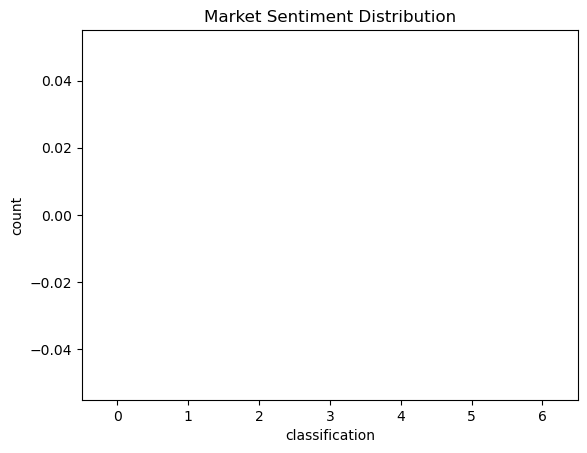

In [35]:
sns.countplot(data=merged_df, x='classification')
plt.title('Market Sentiment Distribution')
plt.show()

In [36]:
print(sentiment_df['Date'].head())
print(trader_df['Date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: Date, dtype: datetime64[ns]
0   1970-01-01
1   1970-01-01
2   1970-01-01
3   1970-01-01
4   1970-01-01
Name: Date, dtype: datetime64[ns]


In [37]:
print(sentiment_df['Date'].dtype)
print(trader_df['Date'].dtype)

datetime64[ns]
datetime64[ns]


In [43]:
print(trader_df['Date'].head(10))
print(trader_df['Date'].min())
print(trader_df['Date'].max())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
5    1970-01-01
6    1970-01-01
7    1970-01-01
8    1970-01-01
9    1970-01-01
Name: Date, dtype: object
1970-01-01
1970-01-01


In [44]:
print(sentiment_df['Date'].head(10))
print(sentiment_df['Date'].min())
print(sentiment_df['Date'].max())

         Date       Date
0  2018-02-01 2018-02-01
1  2018-02-02 2018-02-02
2  2018-02-03 2018-02-03
3  2018-02-04 2018-02-04
4  2018-02-05 2018-02-05
5  2018-02-06 2018-02-06
6  2018-02-07 2018-02-07
7  2018-02-08 2018-02-08
8  2018-02-09 2018-02-09
9  2018-02-10 2018-02-10
Date             2018-02-01
Date    2018-02-01 00:00:00
dtype: object
Date             2025-05-02
Date    2025-05-02 00:00:00
dtype: object


In [45]:
print(trader_df['Date'].unique()[:5])

[datetime.date(1970, 1, 1)]


In [46]:
common_dates = set(trader_df['Date']).intersection(set(sentiment_df['Date']))

print(len(common_dates))

0


In [47]:
print("Trader Data Range:")
print(trader_df['Date'].min(), "to", trader_df['Date'].max())

print()

print("Sentiment Data Range:")
print(sentiment_df['Date'].min(), "to", sentiment_df['Date'].max())

Trader Data Range:
1970-01-01 to 1970-01-01

Sentiment Data Range:
Date             2018-02-01
Date    2018-02-01 00:00:00
dtype: object to Date             2025-05-02
Date    2025-05-02 00:00:00
dtype: object


In [48]:
print(trader_df['Timestamp'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: Timestamp, dtype: object


In [51]:
print(trader_df[['Timestamp', 'Timestamp IST']].head(10))

    Timestamp     Timestamp IST
0  1970-01-01  02-12-2024 22:50
1  1970-01-01  02-12-2024 22:50
2  1970-01-01  02-12-2024 22:50
3  1970-01-01  02-12-2024 22:50
4  1970-01-01  02-12-2024 22:50
5  1970-01-01  02-12-2024 22:50
6  1970-01-01  02-12-2024 22:50
7  1970-01-01  02-12-2024 22:50
8  1970-01-01  02-12-2024 22:50
9  1970-01-01  02-12-2024 22:50


In [50]:
print(trader_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')


In [52]:
trader_df['Date'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

In [53]:
print(trader_df['Date'].head())
print(trader_df['Date'].min())
print(trader_df['Date'].max())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object
2023-05-01
2025-05-01


In [54]:
sentiment_df['Date'] = pd.to_datetime(
    sentiment_df['Date']
).dt.date

ValueError: cannot assemble with duplicate keys

In [55]:
print(sentiment_df.columns)

Index(['timestamp', 'value', 'classification', 'Date', 'Date'], dtype='object')


In [56]:
sentiment_df = sentiment_df.loc[:, ~sentiment_df.columns.duplicated()]

In [58]:
sentiment_df.loc[:, 'Date'] = pd.to_datetime(
    sentiment_df['Date']
).dt.date

In [59]:
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='Date',
    how='left'
)

In [60]:
print(merged_df['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [61]:
merged_df.columns = (
    merged_df.columns
    .str.lower()
    .str.replace(' ', '_')
)

In [62]:
print(merged_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')


In [63]:
merged_df.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

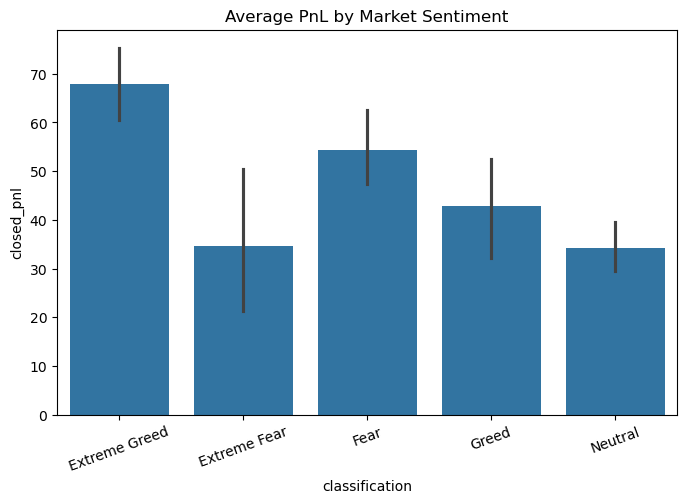

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='closed_pnl'
)

plt.title('Average PnL by Market Sentiment')
plt.xticks(rotation=20)

plt.show()

In [65]:

win_rate = merged_df.groupby('classification')['is_profit'].mean() * 100

print(win_rate)

KeyError: 'Column not found: is_profit'

In [66]:
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

In [67]:
win_rate = merged_df.groupby('classification')['is_profit'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


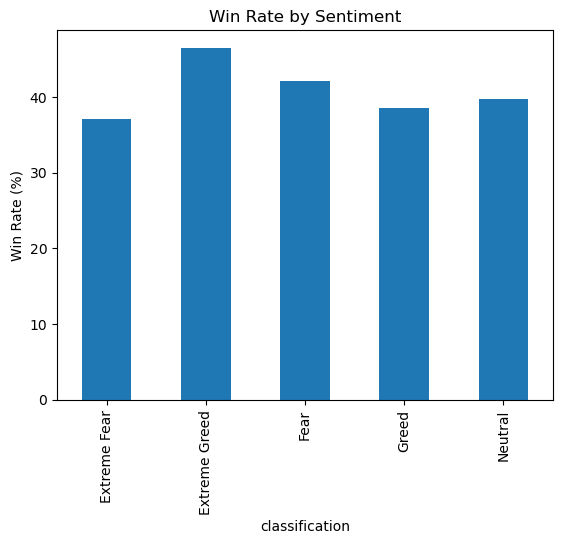

In [68]:
win_rate.plot(kind='bar')

plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')

plt.show()

In [69]:
print(merged_df['side'].unique())

['BUY' 'SELL']


In [70]:
merged_df.groupby(
    ['classification', 'side']
)['closed_pnl'].mean()

classification  side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: closed_pnl, dtype: float64

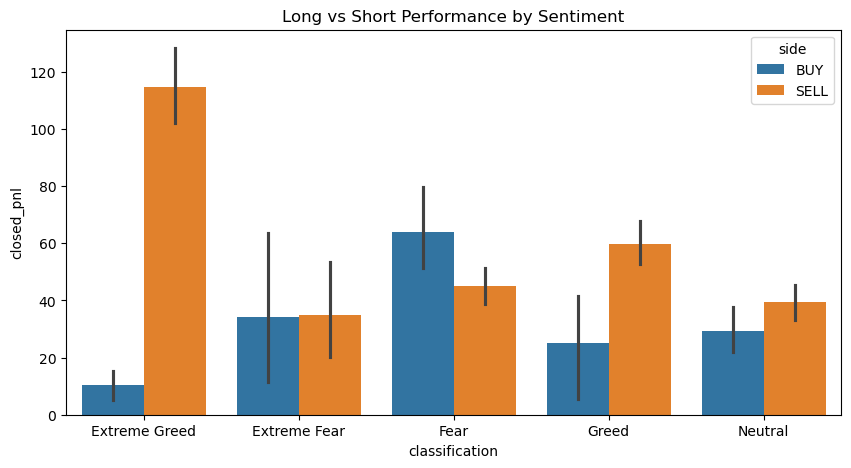

In [71]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='closed_pnl',
    hue='side'
)

plt.title('Long vs Short Performance by Sentiment')

plt.show()

In [72]:
daily_pnl = merged_df.groupby('date')['closed_pnl'].sum().reset_index()

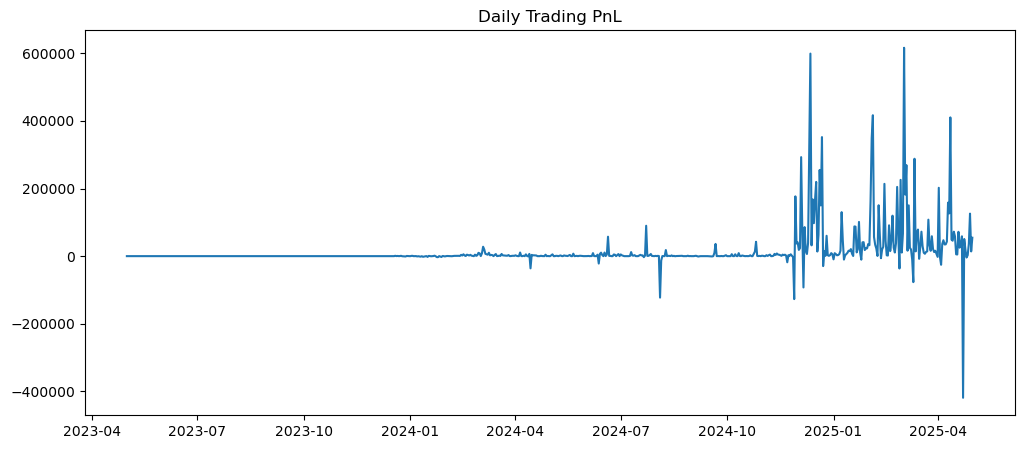

In [73]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_pnl['date'],
    daily_pnl['closed_pnl']
)

plt.title('Daily Trading PnL')

plt.show()

In [74]:
top_traders = merged_df.groupby('account')['closed_pnl'].sum()

top_traders.sort_values(
    ascending=False
).head(10)

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: closed_pnl, dtype: float64

- Item 1 The analysis demonstrates a strong relationship between market sentiment and trader behavior. Extreme Greed periods generated the highest profitability and trading activity, while Fear periods encouraged more defensive and cautious trading patterns. Contrarian strategies — such as buying during Fear and selling during Extreme Greed — appeared more effective than emotionally driven momentum trading.
- Item 2 The results suggest that incorporating sentiment indicators into trading strategies can significantly improve decision-making, profitability, and risk management in cryptocurrency markets.

In [2]:
print(sentiment_df.shape)
print(trader_df.shape)

NameError: name 'sentiment_df' is not defined